# Figures

Last-minute figures for the write-up. Each section is self-contained.

## 1. Where the rice pixels are, with significant states highlighted

Peak GCVI 2023 at **300 m** under the Jordi rice mask — **single national model** —
drawn for every state that has a 300 m export, on one India map.

Two highlight groups, both judged on the state's own **Jordi 1-model** correlation:

| outline | meaning | states |
|---|---|---|
| solid blue, heavy | survives Benjamini–Hochberg, FDR 5% | Madhya Pradesh, Bihar, Chhattisgarh, Punjab, Telangana, West Bengal, Maharashtra, Uttar Pradesh |
| dashed orange | p < 0.05 but does not survive BH | Karnataka, Tamil Nadu |

Each highlighted state is labelled with **Δr = r(Jordi 1-model) − r(raw)**, the change in
the GCVI–yield correlation when the rice mask is applied.

Under Jordi-1 at p < 0.05 there are 10 states: the 8 BH survivors plus Karnataka and
Tamil Nadu. Change `BH` / `SIG` in the next cell to adjust either group.

In [1]:
import os, re, glob, warnings
import numpy as np, pandas as pd, nbformat
import geopandas as gpd, rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 14, 'axes.titlesize': 17, 'axes.labelsize': 15,
    'xtick.labelsize': 13, 'ytick.labelsize': 13,
    'legend.fontsize': 13, 'legend.title_fontsize': 13, 'figure.titlesize': 20,
})

ROOT = '..'
OUT  = f'{ROOT}/outputs'
YEAR = 2023

_nb  = nbformat.read(f'{ROOT}/notebooks/02_mask_analysis/gsv_preds_exploration.ipynb', as_version=4)
_src = next(c.source for c in _nb.cells if c.get('id') == 'ee4f17d1')
_src = _src.replace("os.makedirs('outputs', exist_ok=True)", "").replace("'../../data/", f"'{ROOT}/data/")
CFG = {}; exec(_src, CFG)
REGIONS, REGION_LABELS = CFG['REGIONS'], CFG['REGION_LABELS']

# Highlight groups, judged on each state's own Jordi 1-model correlation in 2023:
#   BH  -> survives Benjamini-Hochberg at FDR 5%
#   SIG -> p < 0.05 but does not survive BH
BH  = ['mp', 'bihar', 'chhattisgarh', 'punjab', 'telangana', 'wb', 'maharashtra', 'up']
SIG = ['karnataka', 'tamil_nadu']

# Delta r = r(Jordi 1-model) - r(raw), from the 2023 300 m analysis
CORR = pd.read_csv(f'{OUT}/gcvi_2023_300m_correlation.csv')
CORR['dr'] = CORR.r_jordi_300m - CORR.r_raw_300m
DR = dict(zip(CORR.region_key, CORR.dr))
PV = dict(zip(CORR.region_key, CORR.p_jordi_300m))

FILE_KEY = {}
for f in glob.glob(f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_*_raw_300m.tif'):
    fk = re.search(rf'{YEAR}_(.+)_raw_300m\.tif', f).group(1)
    FILE_KEY[{'west_bengal': 'wb'}.get(fk, fk)] = fk
STATES = sorted(k for k in FILE_KEY if k in REGIONS)
print(f"{len(STATES)} states with 300 m exports")
print(f"\nBH survivors ({len(BH)}):")
for k in BH:
    print(f"   {REGION_LABELS.get(k,k):<18} dr = {DR.get(k, float('nan')):+.3f}   "
          f"p(Jordi-1) = {PV.get(k, float('nan')):.4f}")
print(f"p < 0.05, not BH ({len(SIG)}):")
for k in SIG:
    print(f"   {REGION_LABELS.get(k,k):<18} dr = {DR.get(k, float('nan')):+.3f}   "
          f"p(Jordi-1) = {PV.get(k, float('nan')):.4f}")
missing = [k for k in BH + SIG if k not in STATES]
print(f"\nhighlighted states without a 300 m file: {missing if missing else 'none'}")

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


Configured 30 states.
27 states with 300 m exports

BH survivors (8):
   Madhya Pradesh     dr = +0.523   p(Jordi-1) = 0.0000
   Bihar              dr = +0.198   p(Jordi-1) = 0.0000
   Chhattisgarh       dr = +0.411   p(Jordi-1) = 0.0000
   Punjab             dr = +0.027   p(Jordi-1) = 0.0004
   Telangana          dr = +0.482   p(Jordi-1) = 0.0063
   West Bengal        dr = +0.902   p(Jordi-1) = 0.0083
   Maharashtra        dr = -0.138   p(Jordi-1) = 0.0103
   Uttar Pradesh      dr = +0.183   p(Jordi-1) = 0.0104
p < 0.05, not BH (2):
   Karnataka          dr = +0.622   p(Jordi-1) = 0.0496
   Tamil Nadu         dr = +0.110   p(Jordi-1) = 0.0401

highlighted states without a 300 m file: none


In [2]:
MAXDIM = 1400          # cap the long side of each raster on read, to bound memory


def read_small(path):
    """Read a raster downsampled so its long side is <= MAXDIM. Returns (array, extent)."""
    with rasterio.open(path) as s:
        f = max(1, int(np.ceil(max(s.height, s.width) / MAXDIM)))
        a = s.read(1, out_shape=(1, s.height // f, s.width // f),
                   resampling=Resampling.average).astype('float32')
        nd, b = s.nodata, s.bounds
    a[~np.isfinite(a)] = np.nan
    if nd is not None:
        a[a == nd] = np.nan
    a[a <= 0] = np.nan                     # empty-mask pixels are not rice
    return a, [b.left, b.right, b.bottom, b.top]


def state_outline(k):
    g = gpd.read_file(REGIONS[k]['shp']).to_crs('EPSG:4326')
    g = g[g.geometry.notna() & ~g.geometry.is_empty]
    if (g.geometry.geom_type == 'GeometryCollection').any():
        g = g.explode(index_parts=False)
        g = g[g.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]
    return g.dissolve()                    # one polygon per state


OUTLINE = {k: state_outline(k) for k in STATES}
print(f"{len(OUTLINE)} state outlines loaded")

# common colour scale from a sample of the single-model rasters
_vals = []
for k in STATES[:12]:
    a, _ = read_small(f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{FILE_KEY[k]}_jordi_300m.tif')
    v = a[np.isfinite(a)]
    if v.size:
        _vals.append(np.random.choice(v, size=min(v.size, 40000), replace=False))
_v = np.concatenate(_vals)
VMIN, VMAX = np.percentile(_v, [2, 98])
print(f"colour scale: {VMIN:.2f} to {VMAX:.2f} peak GCVI")

27 state outlines loaded


colour scale: 1.59 to 7.39 peak GCVI


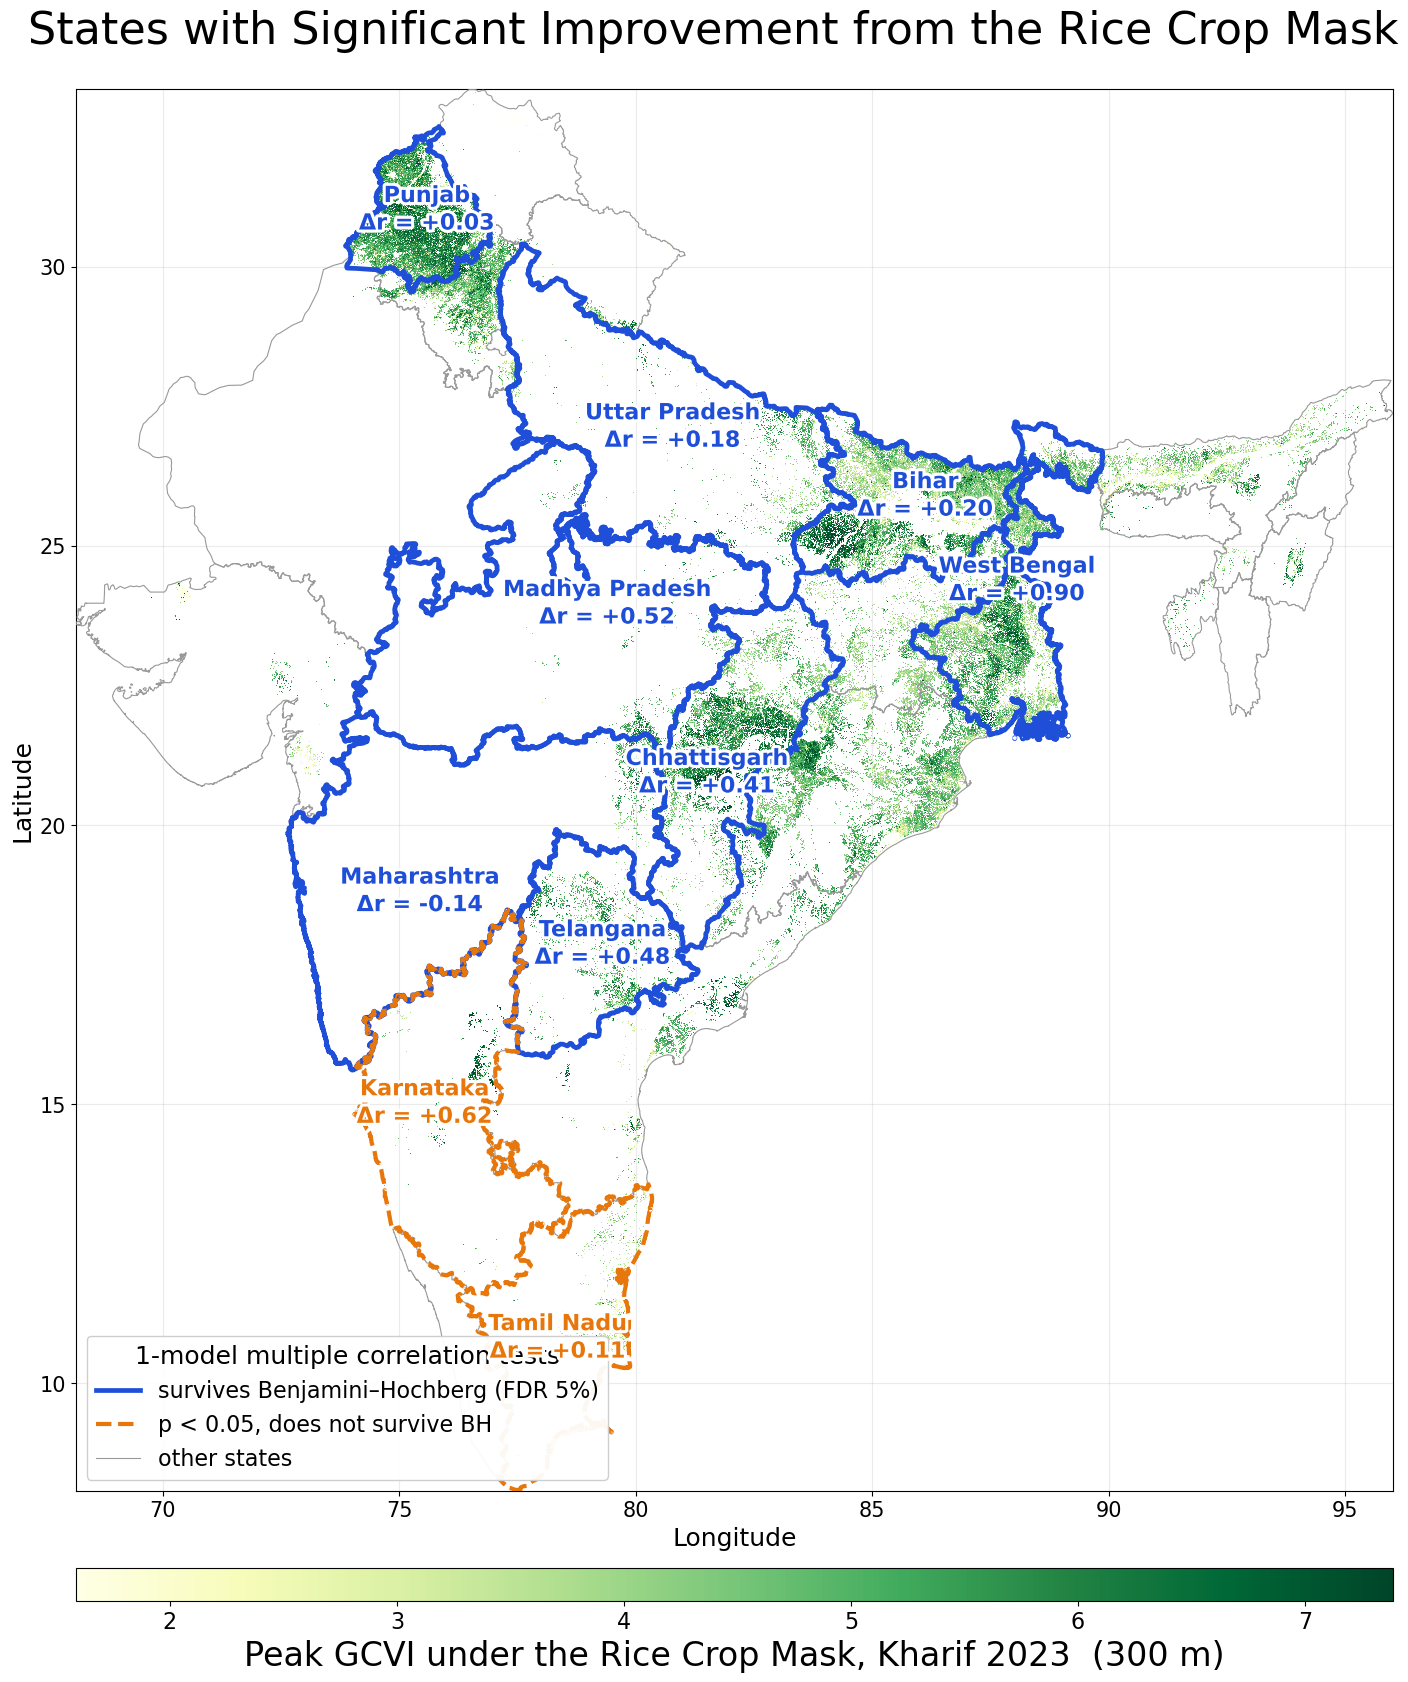

In [3]:
MASKS = [('jordi_300m', 'Jordi rice mask — single national model')]

fig, axes = plt.subplots(1, 1, figsize=(17, 20), squeeze=False)
axes = axes.ravel()
norm = Normalize(vmin=VMIN, vmax=VMAX)

for ax, (mk, title) in zip(axes, MASKS):
    n_px = 0
    for k in STATES:
        tif = f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{FILE_KEY[k]}_{mk}.tif'
        if os.path.exists(tif):
            a, ext = read_small(tif)
            n_px += int(np.isfinite(a).sum())
            ax.imshow(a, cmap='YlGn', norm=norm, extent=ext, origin='upper',
                      interpolation='nearest', zorder=2)
    # boundaries: thin grey for all, then the two highlight groups on top
    for k in STATES:
        if k not in BH + SIG:
            OUTLINE[k].boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.8, zorder=3)
    for grp, colr, lw, ls in [(BH, '#1f4fd8', 3.4, '-'), (SIG, '#e8770b', 3.0, '--')]:
        for k in grp:
            if k not in OUTLINE:
                continue
            OUTLINE[k].boundary.plot(ax=ax, edgecolor=colr, linewidth=lw,
                                     linestyle=ls, zorder=4)
            c = OUTLINE[k].geometry.iloc[0].representative_point()
            ax.annotate(f"{REGION_LABELS.get(k, k)}\nΔr = {DR.get(k, float('nan')):+.2f}",
                        (c.x, c.y), fontsize=16, fontweight='bold', color=colr,
                        ha='center', va='center', zorder=6, linespacing=1.25,
                        path_effects=[pe.withStroke(linewidth=4.5, foreground='white')])

    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([], [], color='#1f4fd8', lw=3.4, ls='-',
               label='survives Benjamini–Hochberg (FDR 5%)'),
        Line2D([], [], color='#e8770b', lw=3.0, ls='--',
               label='p < 0.05, does not survive BH'),
        Line2D([], [], color='#999999', lw=0.8, ls='-', label='other states')],
        loc='lower left', fontsize=16, framealpha=0.95,
        title='1-model multiple correlation tests', title_fontsize=18)
    ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(labelsize=15)
    ax.set_aspect('auto'); ax.grid(alpha=0.25, lw=0.8)
    # ax.set_title(f'{title}\n{n_px:,} retained pixels drawn (downsampled)',
    #              fontsize=21, linespacing=1.4)

cb = fig.colorbar(ScalarMappable(norm=norm, cmap='YlGn'), ax=list(axes),
                  orientation='horizontal', fraction=0.04, pad=0.05, aspect=40)
cb.set_label(f'Peak GCVI under the Rice Crop Mask, Kharif {YEAR}  (300 m)', fontsize=24)
cb.ax.tick_params(labelsize=16)

fig.suptitle(f'States with Significant Improvement from the Rice Crop Mask', y=0.92, fontsize=32)
# plt.savefig(f'{OUT}/fig_rice_pixels_india_300m.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Top-10 rice producing states

The ten largest rice producers (DAFW Final Estimates 2024-25): Uttar Pradesh 20.76,
Telangana 17.45, West Bengal 16.02, Punjab 14.36, Chhattisgarh 10.37, Odisha 9.53,
Madhya Pradesh 9.11, Bihar 8.30, Andhra Pradesh 8.16, Tamil Nadu 7.09 Mt.

Same base map and styling as figure 1. Outlines:

| outline | meaning |
|---|---|
| solid blue | already highlighted — survives Benjamini–Hochberg |
| dashed orange | already highlighted — p < 0.05, not BH |
| **solid red** | **top-10 producer NOT highlighted in figure 1** |

Labels give production rank and Δr = r(Jordi 1-model) − r(raw).

In [4]:
# Top-10 rice producers, DAFW Final Estimates 2024-25 (million tonnes)
TOP10 = {'up': (1, 20.76), 'telangana': (2, 17.45), 'wb': (3, 16.02), 'punjab': (4, 14.36),
         'chhattisgarh': (5, 10.37), 'odisha': (6, 9.53), 'mp': (7, 9.11), 'bihar': (8, 8.30),
         'andhra_pradesh': (9, 8.16), 'tamil_nadu': (10, 7.09)}

PREV = set(BH) | set(SIG)                       # highlighted in figure 1
NEW  = [k for k in TOP10 if k not in PREV]      # top-10 producers not yet highlighted

print(f"top-10 producers: {len(TOP10)}   already highlighted: {len(set(TOP10) & PREV)}")
print(f"NOT in figure 1 -> outlined red: {', '.join(REGION_LABELS.get(k, k) for k in NEW)}\n")
print(f"{'rank':>4}  {'state':<17}{'Mt':>7}{'dr':>8}{'p(J1)':>9}  group")
for k, (rk, mt) in sorted(TOP10.items(), key=lambda x: x[1][0]):
    grp = 'BH' if k in BH else 'p<0.05' if k in SIG else 'NOT highlighted'
    print(f"{rk:>4}  {REGION_LABELS.get(k,k):<17}{mt:>7.2f}{DR.get(k,float('nan')):>8.3f}"
          f"{PV.get(k,float('nan')):>9.4f}  {grp}")

top-10 producers: 10   already highlighted: 8
NOT in figure 1 -> outlined red: Odisha, Andhra Pradesh

rank  state                 Mt      dr    p(J1)  group
   1  Uttar Pradesh      20.76   0.183   0.0104  BH
   2  Telangana          17.45   0.482   0.0063  BH
   3  West Bengal        16.02   0.902   0.0083  BH
   4  Punjab             14.36   0.027   0.0004  BH
   5  Chhattisgarh       10.37   0.411   0.0000  BH
   6  Odisha              9.53   0.246   0.6188  NOT highlighted
   7  Madhya Pradesh      9.11   0.523   0.0000  BH
   8  Bihar               8.30   0.198   0.0000  BH
   9  Andhra Pradesh      8.16   0.241   0.9687  NOT highlighted
  10  Tamil Nadu          7.09   0.110   0.0401  p<0.05


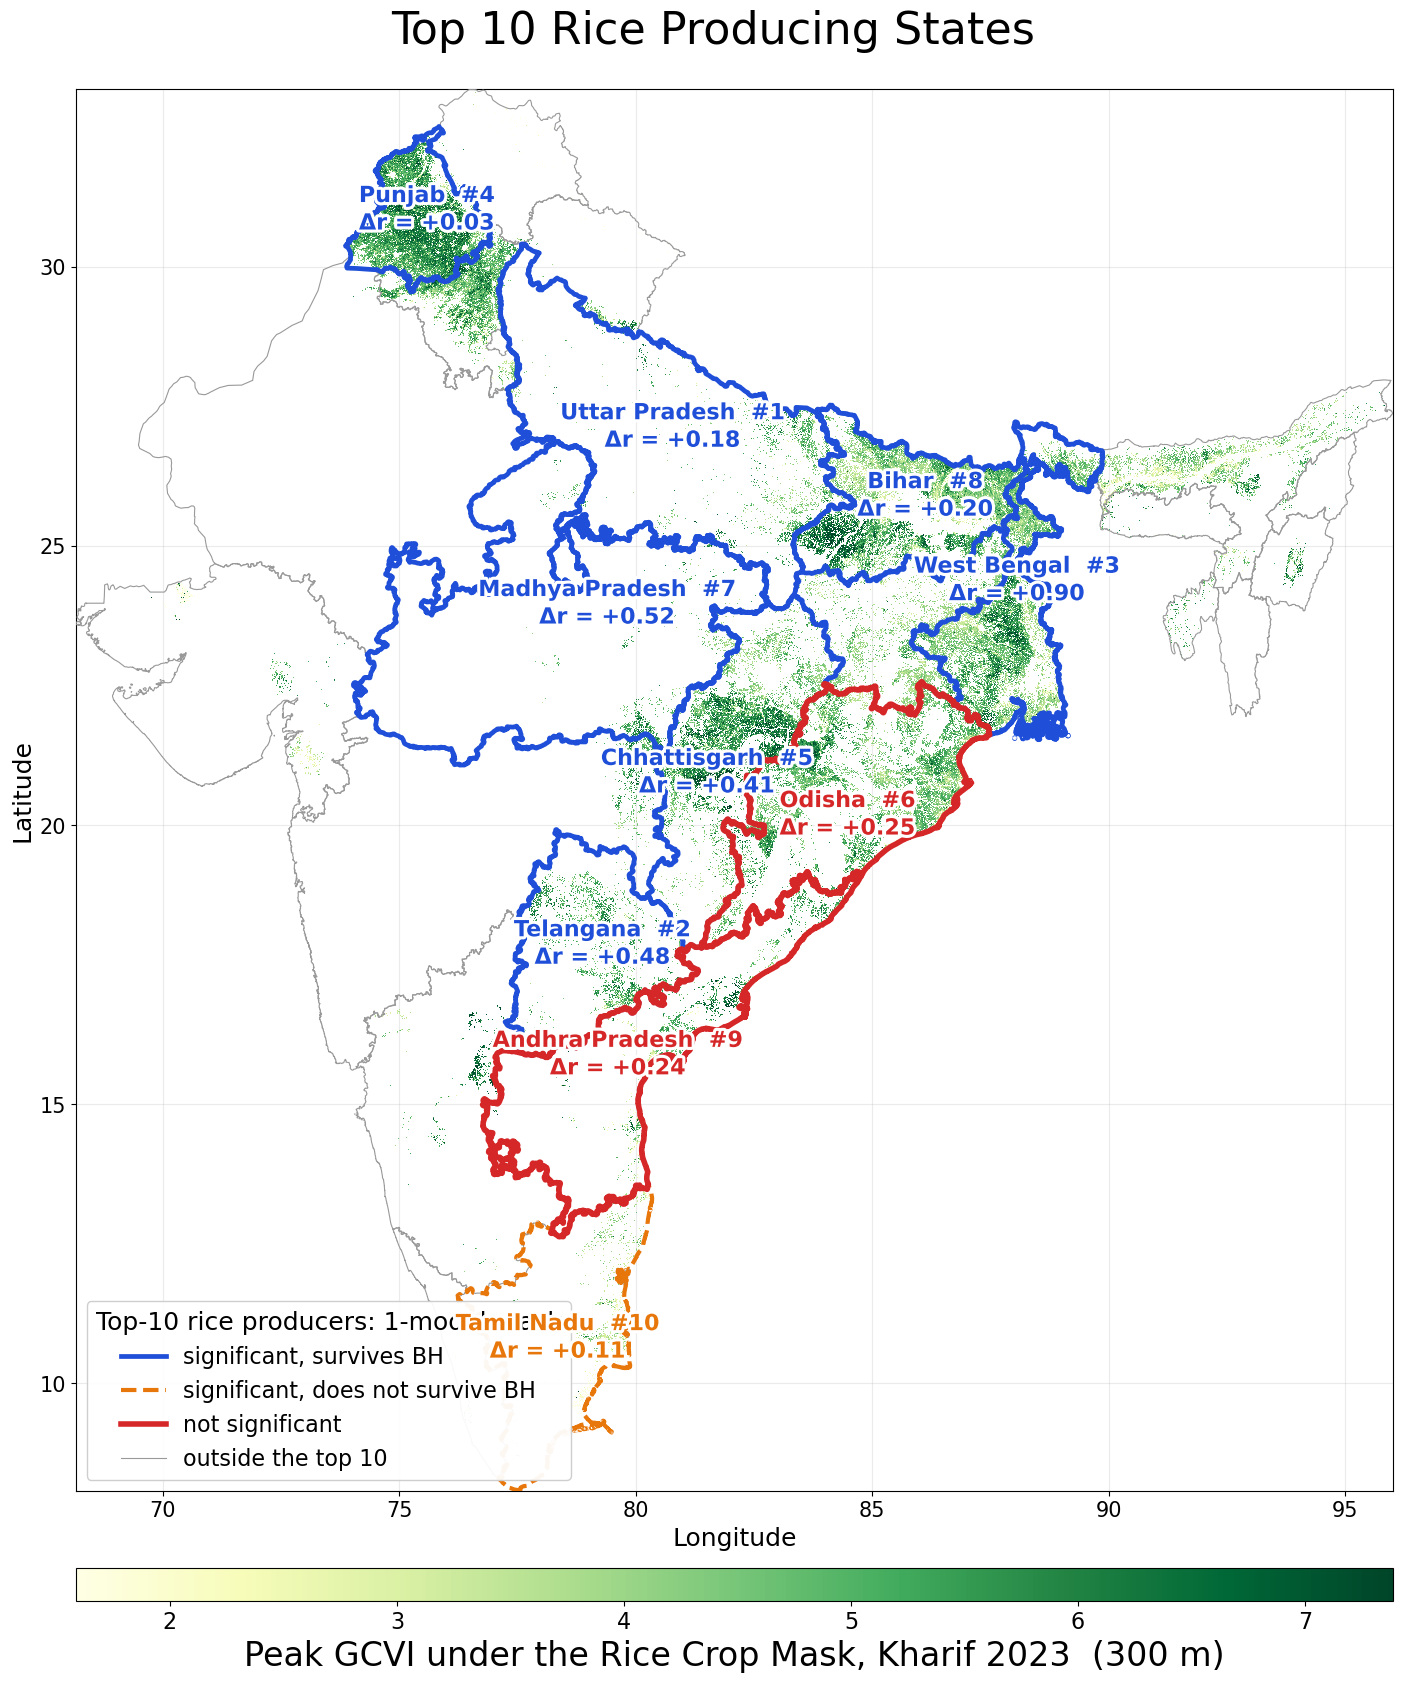

In [5]:
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 1, figsize=(17, 20), squeeze=False)
axes = axes.ravel()
norm = Normalize(vmin=VMIN, vmax=VMAX)
mk = 'jordi_300m'

for ax in axes:
    for k in STATES:
        tif = f'{ROOT}/data/gcvi/peak_gcvi_kharif_{YEAR}_{FILE_KEY[k]}_{mk}.tif'
        if os.path.exists(tif):
            a, ext = read_small(tif)
            ax.imshow(a, cmap='YlGn', norm=norm, extent=ext, origin='upper',
                      interpolation='nearest', zorder=2)

    for k in STATES:                                   # everything not in the top 10
        if k not in TOP10:
            OUTLINE[k].boundary.plot(ax=ax, edgecolor='#999999', linewidth=0.8, zorder=3)

    GROUPS = [([k for k in TOP10 if k in BH],  '#1f4fd8', 3.4, '-'),
              ([k for k in TOP10 if k in SIG], '#e8770b', 3.0, '--'),
              (NEW,                            '#d62728', 4.0, '-')]
    for grp, colr, lw, ls in GROUPS:
        for k in grp:
            if k not in OUTLINE:
                continue
            OUTLINE[k].boundary.plot(ax=ax, edgecolor=colr, linewidth=lw,
                                     linestyle=ls, zorder=5)
            c = OUTLINE[k].geometry.iloc[0].representative_point()
            ax.annotate(f"{REGION_LABELS.get(k, k)}  #{TOP10[k][0]}\n"
                        f"Δr = {DR.get(k, float('nan')):+.2f}",
                        (c.x, c.y), fontsize=16, fontweight='bold', color=colr,
                        ha='center', va='center', zorder=6, linespacing=1.25,
                        path_effects=[pe.withStroke(linewidth=4.5, foreground='white')])

    ax.legend(handles=[
        Line2D([], [], color='#1f4fd8', lw=3.4, ls='-',  label='significant, survives BH'),
        Line2D([], [], color='#e8770b', lw=3.0, ls='--', label='significant, does not survive BH'),
        Line2D([], [], color='#d62728', lw=4.0, ls='-',  label='not significant'),
        Line2D([], [], color='#999999', lw=0.8, ls='-',  label='outside the top 10')],
        loc='lower left', fontsize=16, framealpha=0.95,
        title='Top-10 rice producers: 1-model mask', title_fontsize=18)
    ax.set_xlabel('Longitude', fontsize=18); ax.set_ylabel('Latitude', fontsize=18)
    ax.tick_params(labelsize=15)
    ax.set_aspect('auto'); ax.grid(alpha=0.25, lw=0.8)

cb = fig.colorbar(ScalarMappable(norm=norm, cmap='YlGn'), ax=list(axes),
                  orientation='horizontal', fraction=0.04, pad=0.05, aspect=40)
cb.set_label(f'Peak GCVI under the Rice Crop Mask, Kharif {YEAR}  (300 m)', fontsize=24)
cb.ax.tick_params(labelsize=16)

fig.suptitle('Top 10 Rice Producing States', y=0.92, fontsize=32)
plt.savefig(f'{OUT}/fig_top10_rice_states.png', dpi=140, bbox_inches='tight')
plt.show()